# FWI com Unets

In [30]:
# %env XLA_FLAGS=--xla_gpu_cuda_data_dir=/home/fmn/miniconda3/pkgs/cuda-nvvm-tools-12.9.86-h4bc722e_2
# %env TF_ENABLE_ONEDNN_OPTS=0

In [31]:
import matplotlib.pyplot as plt

import ipywidgets as widgets
from IPython.display import clear_output


import numpy as np

import tensorflow as tf
from tensorflow.keras import  layers, Model

from geod67lib.unet import create_migration_map
from geod67lib.normalization import create_normalization_transforms
from geod67lib.plotting import plot_image, plot_seismogram
from geod67lib.wavefield import WaveSolverLayer, AquisitionParameters, generate_damp_mask



## Modelo de velocidade e imagem migrada

In [32]:
# shape = (1024, 512)
# shape = (256, 256)
# spacing = (10, 10)
shape = (128, 128)
spacing = (20, 20)

width, height = (shape[0] - 1)*spacing[0], (shape[1] - 1)*spacing[1]

In [33]:
vp_true = np.fromfile(f'./data/marmo_vp_nx{shape[0]}nz{shape[1]}dx{spacing[0]}dz{spacing[1]}.bin', dtype=np.float32).reshape((1, shape[0], shape[1], 1))
vp_0 = np.fromfile(f'./data/vp0_nx{shape[0]}nz{shape[1]}dx{spacing[0]}dz{spacing[1]}.bin', dtype=np.float32).reshape((1, shape[0], shape[1], 1))
zeta = np.fromfile(f'./data/mig_nx{shape[0]}nz{shape[1]}dx{spacing[0]}dz{spacing[1]}.bin', dtype=np.float32).reshape((1, shape[0], shape[1], 1))

In [34]:
vpmin = vp_true.min()*.9
vpmax = vp_true.max()*1.1

vpmin, vpmax

(np.float32(1.3499999), np.float32(4.895))

In [35]:
normalize, denormalize = create_normalization_transforms(vpmin, vpmax)

In [36]:
m_0 = normalize(tf.constant(vp_0))

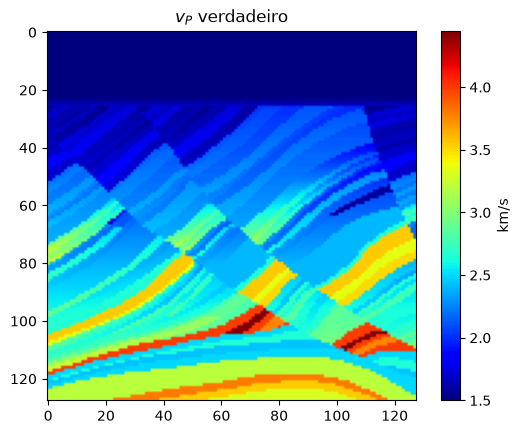

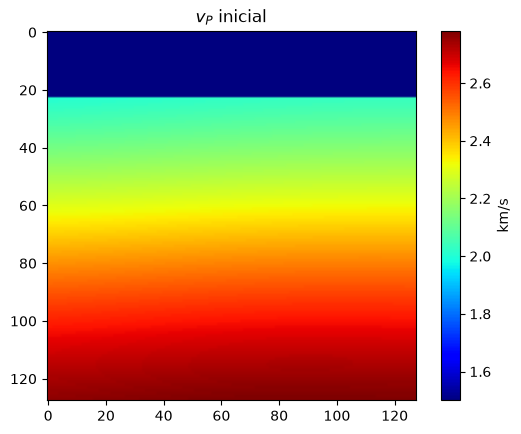

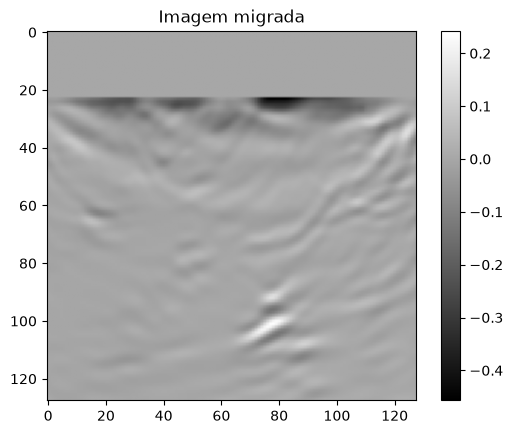

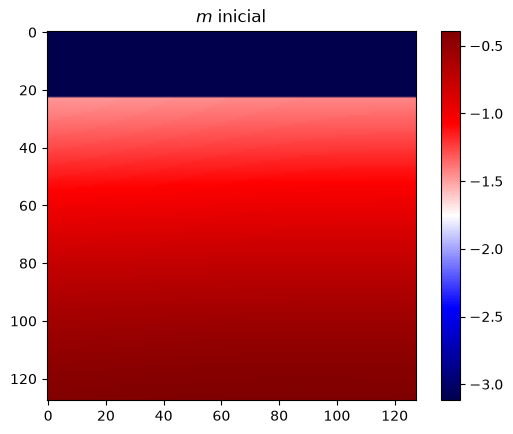

In [37]:
plot_image(vp_true, title='$v_P$ verdadeiro', label='km/s')
plot_image(vp_0, title='$v_P$ inicial', label='km/s')
plot_image(zeta, title='Imagem migrada', cmap='gray')
plot_image(m_0.numpy(), title='$m$ inicial', cmap='seismic')

## Construção da Rede

In [38]:
migmap = create_migration_map(*shape)

In [39]:
zeta_in = tf.constant(zeta)
np.min(zeta_in), np.max(zeta_in)

(np.float32(-0.45678365), np.float32(0.2425648))

In [40]:
dm = migmap(zeta_in)
np.min(dm), np.max(dm)

(np.float32(-0.17504252), np.float32(0.12206341))

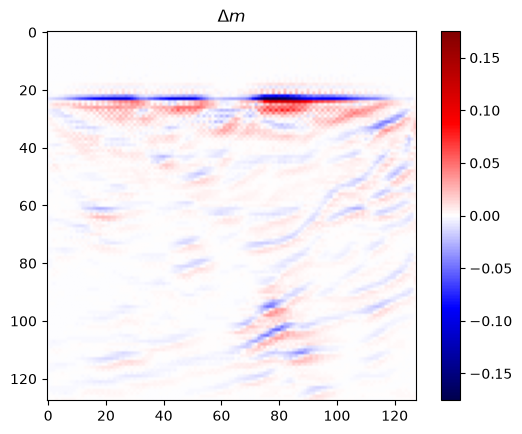

In [41]:
d = dm.numpy()
d = d - np.median(d)
plot_image(d, cmap='seismic', vmin=-np.abs(d).max(), vmax=np.abs(d).max(), title='$\\Delta m$')

## Operador de modelagem

In [42]:
nbl = 20

In [43]:
ap = AquisitionParameters.load('./data/aquisition-params.json')

nrec = ap.nrec
nsrc = ap.nsrc
nt = ap.nt

src_positions = ap.src_positions
ap.src_positions = np.zeros((1, 2))

In [44]:
vp0_pad = np.pad(vp_0[0, :, :, 0], nbl, mode='edge')
vp0_pad = vp0_pad.reshape((1, *vp0_pad.shape, 1))
damp_mask = generate_damp_mask(vp0_pad, nbl)
water_mask = np.fromfile(f'data/watermask_nx{shape[0]}nz{shape[1]}dx{spacing[0]}dz{spacing[1]}.bin', dtype=np.int8).reshape(1, *shape, 1)

In [45]:
damp_mask.shape

(1, 168, 168, 1)

## Dado observado

In [46]:
dobs = np.fromfile(f'./data/dobs_nx{shape[0]}nz{shape[1]}dx{spacing[0]}dz{spacing[1]}.bin', dtype=np.float32).reshape(nsrc, nrec, nt)

In [47]:
slider = widgets.IntSlider(min=0, max=nsrc-1, description='Shot index')
@widgets.interact(idx=slider)
def plot_seismogram_interact(idx):
    plot_seismogram(dobs[idx], width, ap.tn)

interactive(children=(IntSlider(value=0, description='Shot index', max=4), Output()), _dom_classes=('widget-in…

## Inversão

In [48]:
migmap.input, migmap.output

(<KerasTensor shape=(None, 128, 128, 1), dtype=float32, sparse=False, ragged=False, name=keras_tensor_46>,
 <KerasTensor shape=(None, 128, 128, 1), dtype=float32, sparse=False, ragged=False, name=keras_tensor_86>)

In [49]:
dm = migmap.output
m = layers.Add()([dm, m_0])
vp_full = layers.Lambda(denormalize)(m)
out = WaveSolverLayer(ap, damp_mask, water_mask, src_positions, spacing=spacing)(vp_full)
out

<KerasTensor shape=(5, 128, 1500), dtype=float32, sparse=False, ragged=False, name=keras_tensor_91>

In [50]:
model = Model(inputs=migmap.input,outputs=out,name='train_net')
model

<Functional name=train_net, built=True>

In [51]:
model.output

<KerasTensor shape=(5, 128, 1500), dtype=float32, sparse=False, ragged=False, name=keras_tensor_91>

In [52]:
# with tf.GradientTape() as g:
#     dcalc = model(zeta_in)
#     res = dcalc - dobs
#     phi = tf.reduce_mean(tf.square(res))

#     grad = g.gradient(phi, model.variables[0])
# grad

In [53]:
model.compile(
    loss=tf.keras.losses.MeanSquaredError(),
    optimizer=tf.keras.optimizers.Adam(),
    metrics=[
        tf.keras.metrics.MeanSquaredError()
    ]
)

In [54]:
x_train = zeta
y_train = dobs.reshape((1, *dobs.shape))

In [55]:
history = model.fit(
    x_train,
    y_train,
    batch_size=1,
    # verbose=2,
    epochs=500
)

Epoch 1/500


KeyboardInterrupt: 

In [ ]:
dm = migmap(zeta)

In [ ]:
migmap.variables

[<Variable path=conv2d/kernel, shape=(3, 3, 1, 8), dtype=float32, value=[[[[-0.14464912  0.03795524  0.03991078  0.267471   -0.12416932
      0.24674837 -0.06211252  0.20834285]]
 
   [[-0.196101    0.14305814 -0.19382831  0.26123607  0.13510267
     -0.12788168  0.02006234 -0.02915812]]
 
   [[ 0.16183409 -0.21685122  0.05502871 -0.00787393 -0.17350902
     -0.2513225  -0.24011293 -0.15661305]]]
 
 
  [[[-0.02987983  0.05801864  0.05697359  0.2646862  -0.0472745
     -0.01599917 -0.14029914  0.13938884]]
 
   [[-0.0876917   0.11774733 -0.24177182  0.02606227 -0.19448066
      0.09789101  0.07574878  0.0047509 ]]
 
   [[-0.15299287  0.18682261 -0.09147007  0.1962936  -0.08211485
     -0.17746589  0.14988042  0.23997429]]]
 
 
  [[[ 0.10551514 -0.1162396  -0.10013077  0.02304831  0.0570677
     -0.23523928  0.11537822 -0.03634704]]
 
   [[-0.18548064 -0.24777794 -0.2556457   0.24008241 -0.14519043
      0.1582528   0.19546025 -0.13772638]]
 
   [[ 0.08687977  0.05865024  0.11803485 -0.1

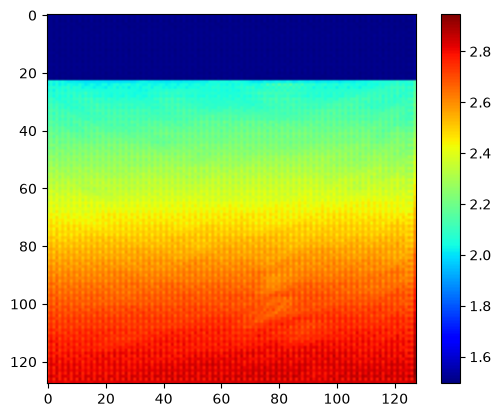

In [ ]:
plot_image(denormalize(dm + m_0).numpy())